# Imports

In [1]:
import pandas as pd
from pathlib import Path
import os
from PIL import Image
import matplotlib.pyplot as plt
import math
import numpy as np

<br>

# Functions

In [3]:
def get_biomarker_samples(random_state=None):
    img_id = df_metadata['img_id'].sample(random_state=random_state).item()
    return df_metadata.query('img_id == @img_id').copy()

In [4]:
def load_image_samples(df_bmarks):
    df_bmarks.loc[:, 'img_tile'] = df_bmarks.apply(lambda row: Image.open(row['path']).convert('RGB'), axis=1)
    return df_bmarks

In [5]:
def plot_ihc_deconv(ihc_bmark_sample):
    fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(12, 10))

    fig.suptitle(ihc_bmark_sample['biomarker'], y=0.65)
    axes = axes.flatten()
    
    axes[0].imshow(ihc_bmark_sample['orig_img'])
    axes[0].set_title('Original Tile')
    
    axes[1].imshow(ihc_bmark_sample['trans_img'])
    axes[1].set_title('Transparent Tile')
    
    axes[2].imshow(ihc_bmark_sample['deconv_img'])
    axes[2].set_title('Deconv Tile')
    
    axes[3].imshow(ihc_bmark_sample['denoised_img'])
    axes[3].set_title('Denoised Tile')
    fig.tight_layout()

In [6]:
def plot_reconstruction(df_bmarks, biomarker='HES', figsize=(12,12), img_col='img_tile'):
    order_by_cols = ['tile_col_offset', 'tile_row_offset']
    df_bmark_sorted = df_bmarks.loc[df_bmarks.biomarker == biomarker, :].sort_values(by=order_by_cols)

    orig_img_nrows = int(math.sqrt(len(df_bmark_sorted)))
    fig, axes = plt.subplots(nrows=orig_img_nrows, ncols=orig_img_nrows, figsize=figsize)
    fig.suptitle(f"Image {df_bmark_sorted['img_id'].iloc[0]}", y=0.99)
    for i, ax in enumerate(axes.ravel()):
        #ax.set_title(f'{biomarker} | tile({i // orig_img_nrows}, {i % orig_img_nrows})')
        ax.imshow(df_bmark_sorted[img_col].iloc[i])
        ax.set_axis_off()
    fig.tight_layout(h_pad=0.1, w_pad=0.1)
    return df_bmark_sorted

In [7]:
def get_reconstructed_image(df_bmarks, image_col, biomarker='HES'):
    orig_img_nrows = int(math.sqrt(len(df_bmark_sorted)))
    order_by_cols = ['tile_col_offset', 'tile_row_offset']
    df_bmarks_sorted = df_bmarks.loc[df_bmarks.biomarker == biomarker, :].sort_values(by=order_by_cols)
    df_bmarks_sorted[image_col].values.reshape(orig_img_nrows, orig_img_nrows)

<br>

# Read Sample Images

In [8]:
df_metadata = pd.read_parquet('../data/02_intermediate/spatial-attention-pcr/metadata.parquet')

df_bmarkers_samples = get_biomarker_samples(520)

In [9]:
df_bmarkers_samples = load_image_samples(df_bmarkers_samples)

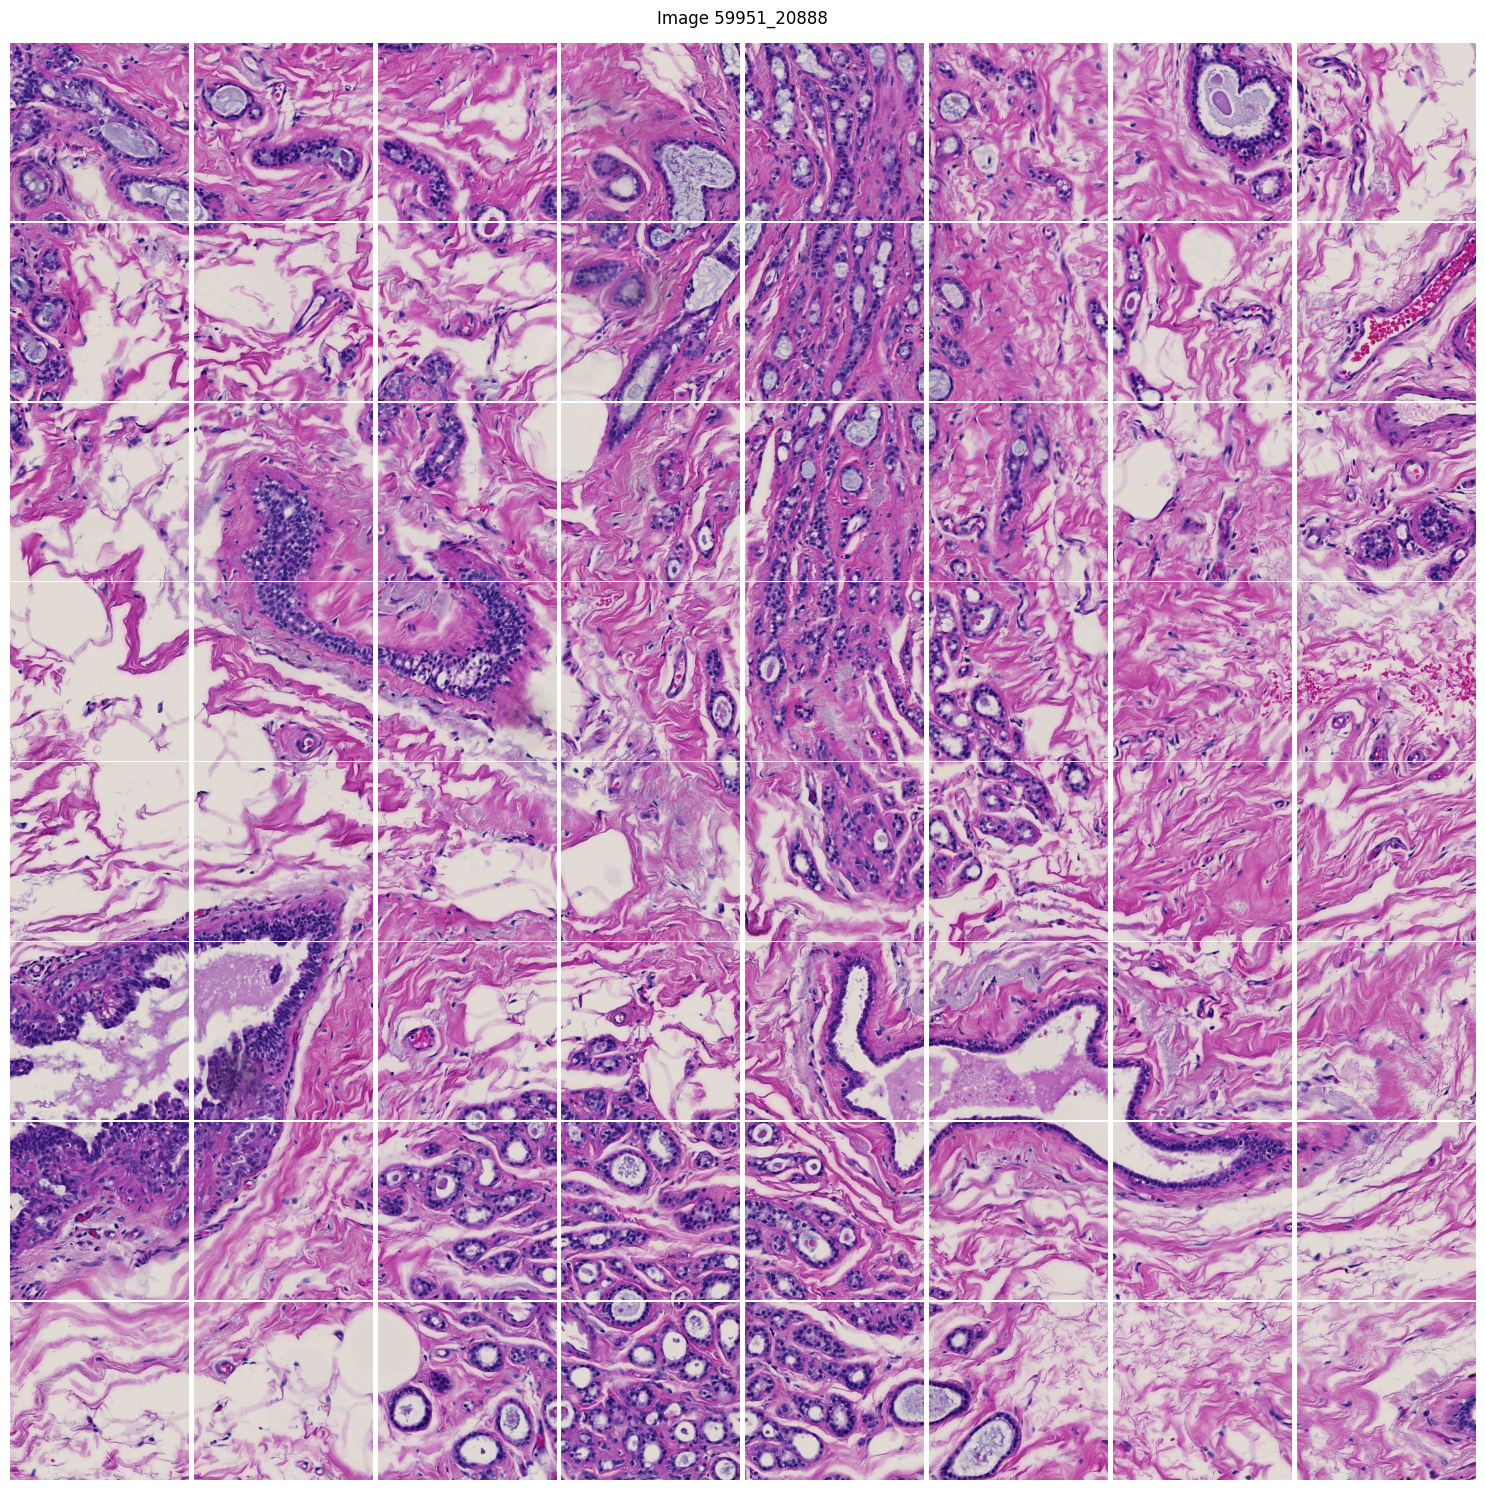

In [10]:
bmark_sorted = plot_reconstruction(df_bmarkers_samples, biomarker='HES', figsize=(15,15))

<br>

# Read Segmented Images 

In [11]:
BASE_TILE_DIR = '/home_cerberus/speed/daniel.ayala/breast-cancer-segmentation/bcs-kedro/data/02_intermediate/spatial-attention-pcr'
#BASE_SEGMENTED_DIR = '/home_cerberus/disk3/speed/viniciusfariaresende/breast-cancer-segmentation-storage/output_images_with_filter'
BASE_SEGMENTED_DIR = '/home_cerberus/disk3/speed/viniciusfariaresende/breast-cancer-segmentation-storage/individaully_segmented_masks'

In [12]:
df_bmarkers_samples.loc[df_bmarkers_samples.biomarker == 'HES', 'path_seg'] =  \
df_bmarkers_samples.loc[df_bmarkers_samples.biomarker == 'HES', 'path'].str.replace(BASE_TILE_DIR, BASE_SEGMENTED_DIR).str.replace('.jpg', '.npz')

In [13]:
df_bmarkers_samples.loc[df_bmarkers_samples.biomarker == 'HES', 'img_tile_seg'] = df_bmarkers_samples.loc[df_bmarkers_samples.biomarker == 'HES', 'path_seg'].apply(lambda path: np.load(path)['contours'])

TypeError: Invalid shape (17, 1000, 1000) for image data

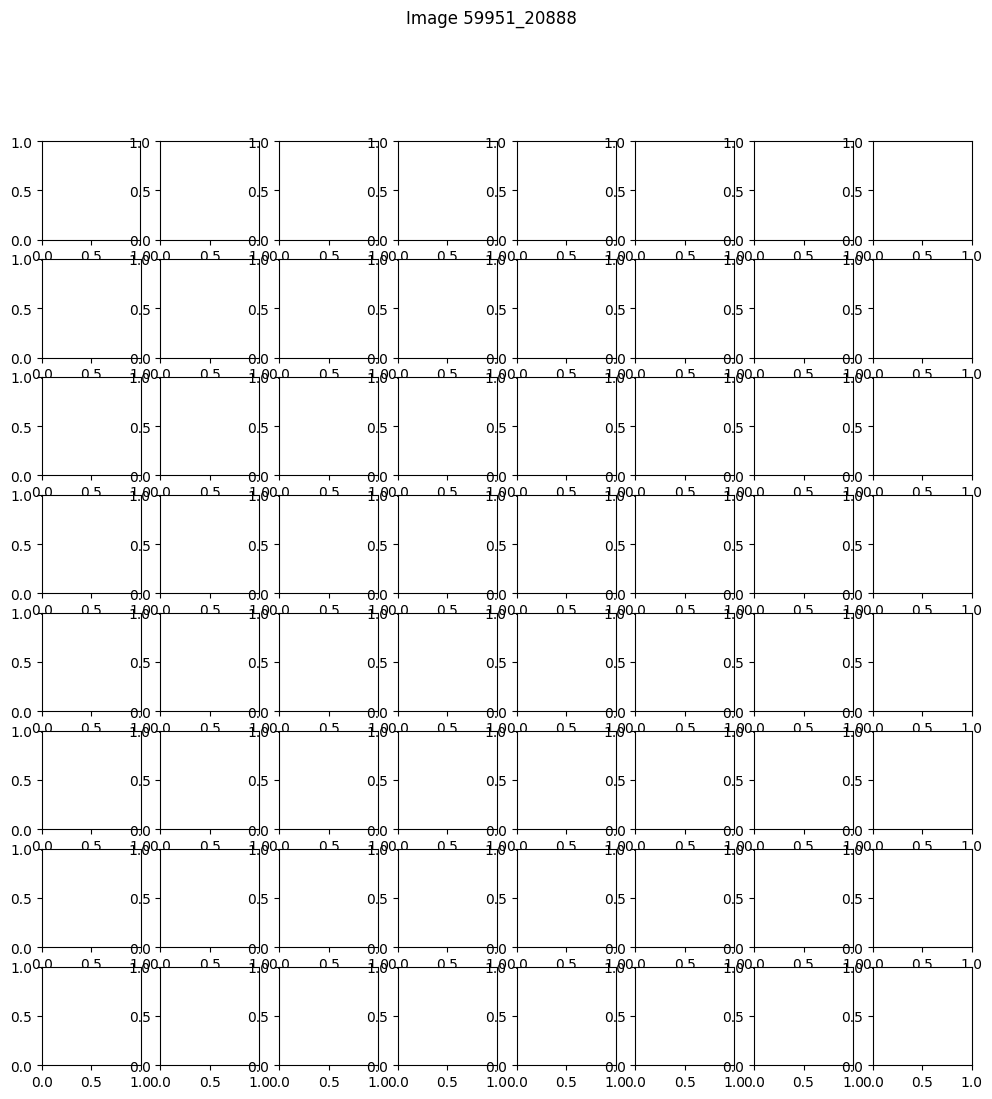

In [14]:
_ = plot_reconstruction(df_bmarkers_samples, biomarker='HES', img_col='img_tile_seg', figsize=(12,12))

In [ ]:
segmented_img_reconstruct = df_bmarkers_samples.loc[df_bmarkers_samples.biomarker == 'HES'].sort_values(by=['tile_col_offset', 'tile_row_offset'])['img_tile_seg'].values

In [14]:
segmented_img_reconstruct = segmented_img_reconstruct.reshape(8,8)

NameError: name 'segmented_img_reconstruct' is not defined

In [ ]:
segmented_img_reconstruct.shape

In [ ]:
# Reshape to a 8x8 grid of images
# segmented_img_reconstruct = segmented_img_reconstruct.reshape(8, 8, 512, 512, 3)

# Concatenate images row by row, and then column by column
# segmented_img_reconstruct = np.concatenate(
    # [np.concatenate(segmented_img_reconstruct[i], axis=1) for i in range(8)], axis=0
#)

TypeError: Image data of dtype object cannot be converted to float

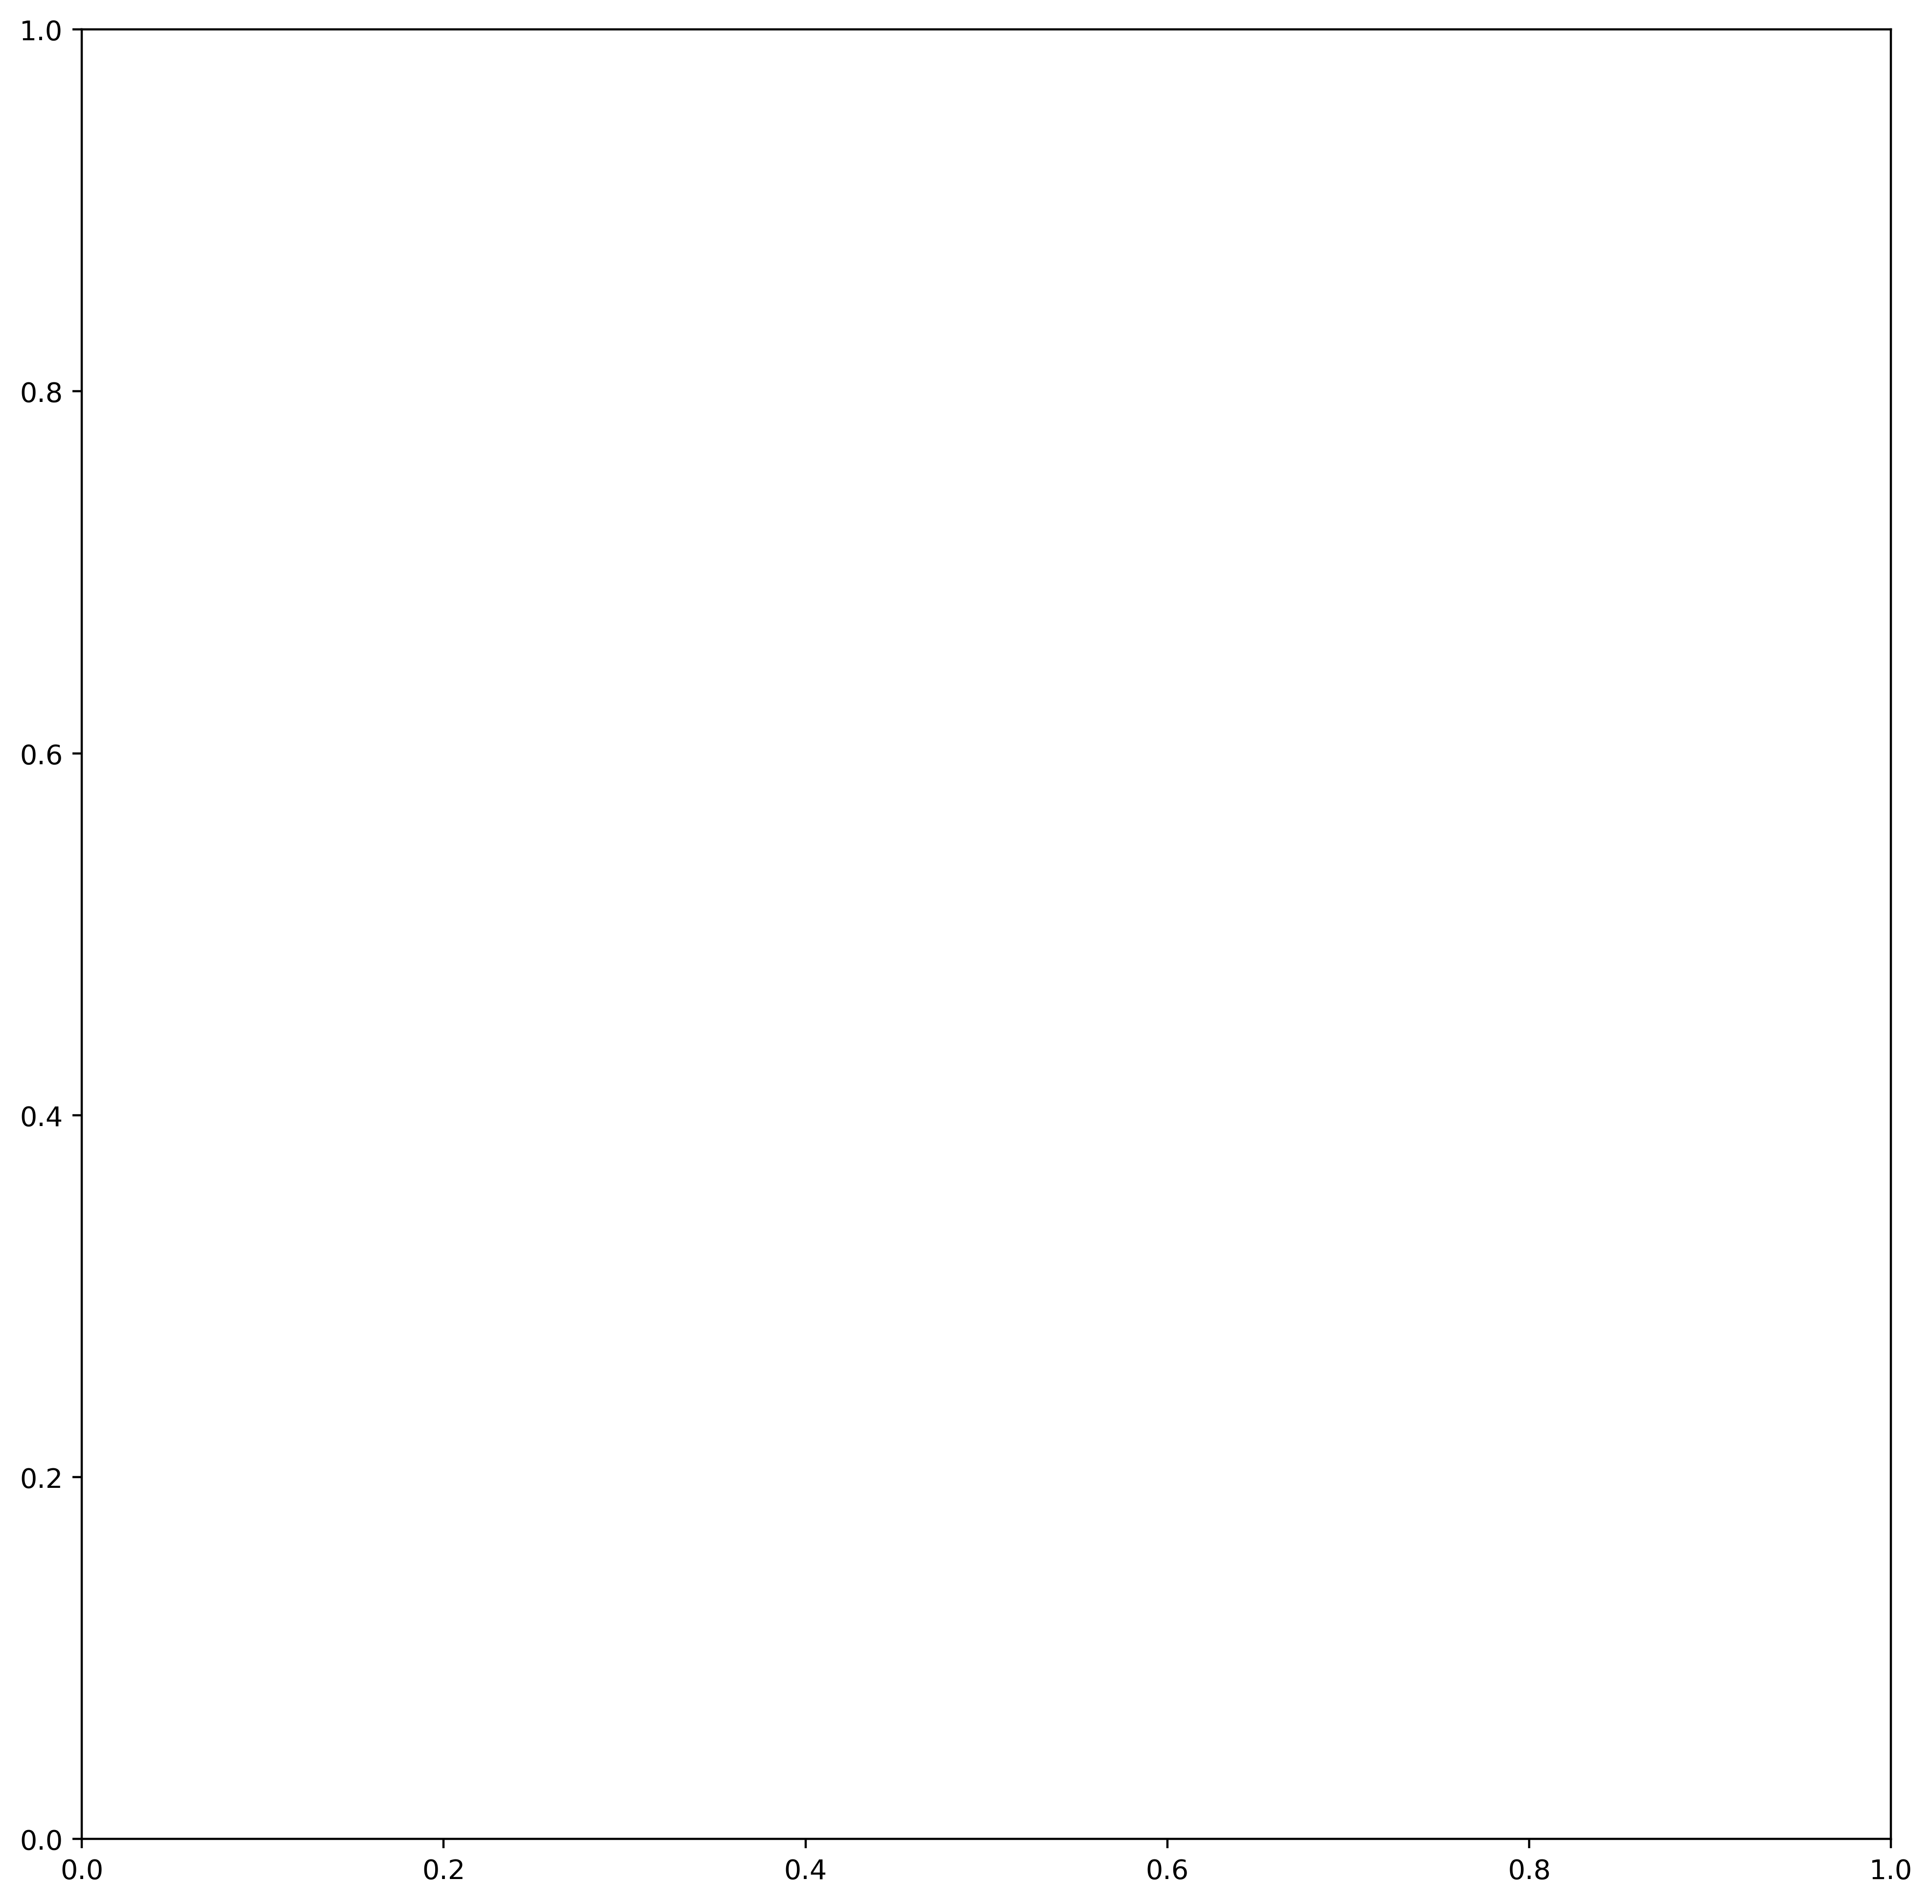

In [36]:
plt.figure(figsize=(12,12), dpi=400)
plt.imshow(segmented_img_reconstruct)

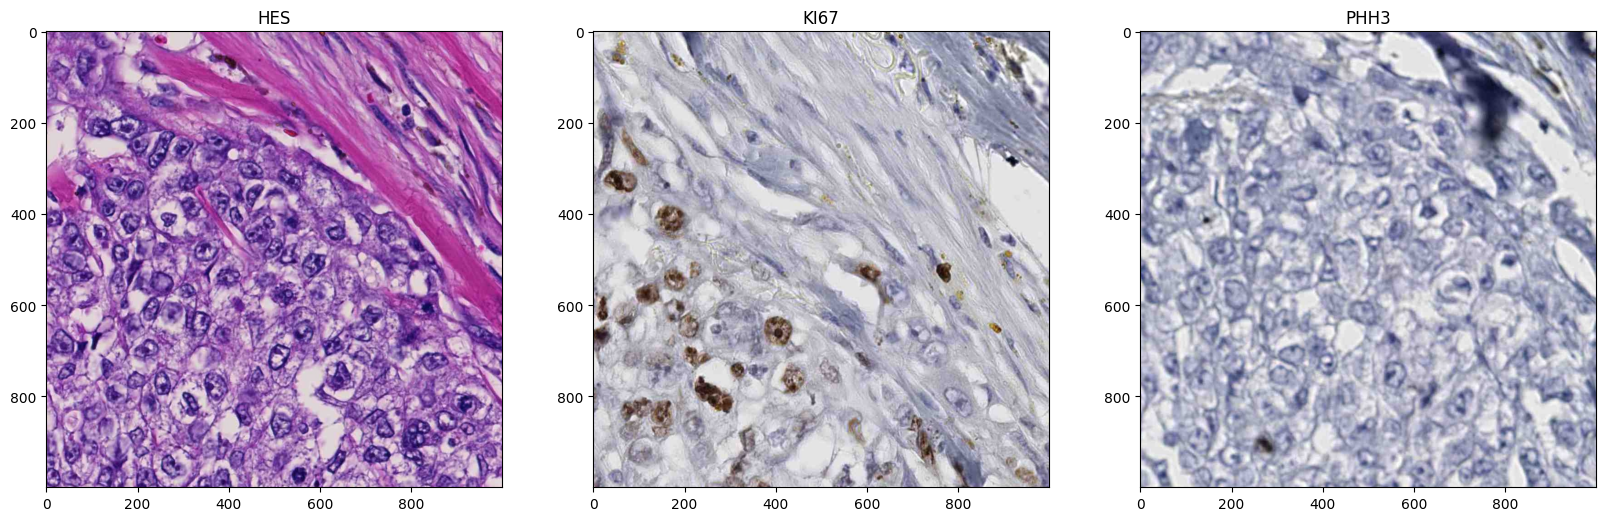

In [ ]:
biomarkers = {}
for i, sample in df_bmarkers_samples.iterrows():
    biomarkers[sample['biomarker']] = Image.open(sample['path']).convert('RGB')

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20,10))
bmarker_order = ['HES', 'KI67', 'PHH3']
for i, ax in enumerate(axes.flatten()):
    ax.set_title(bmarker_order[i])
    ax.imshow(biomarkers[bmarker_order[i]])

<br>

In [6]:
hes_sample_tile_path = df_bmarkers_samples.loc[df_bmarkers_samples.biomarker == 'HES'].iloc[0].path

In [7]:
segmented_sample_path = os.path.join(*[BASE_SEGMENTED_DIR, *Path(hes_sample_tile_path).parts[-2:]])

In [8]:
segmented_image = Image.open(segmented_sample_path).convert('RGB')

<br>

# Apply Color Deconvolution

In [15]:
from color_deconv import apply_color_deconv

In [16]:
color_deconv_params = {
    'area_threshold': [50,100,150],
    'transparent_strength': 2.5,
    'dab_threshold': 0.31
}

In [17]:
# Filters Ki67 and PHH3
df_ihc_bmark = df_bmarkers_samples.loc[df_bmarkers_samples.biomarker != 'HES', :].copy()

In [18]:
df_ihc_bmark['orig_img'] = np.nan
df_ihc_bmark['trans_img'] = np.nan
df_ihc_bmark['deconv_img'] = np.nan
df_ihc_bmark['denoised_img'] = np.nan

In [ ]:
for i, ihc_biomarker_sample in df_ihc_bmark.iterrows():
    trans_img, deconv_img, denoised_img = apply_color_deconv(ihc_biomarker_sample.path, **color_deconv_params)
    #df_ihc_bmark.loc[i, 'orig_img'] = Image.open(ihc_biomarker_sample.path).convert('RGB')
    #df_ihc_bmark.loc[i, 'trans_img'] = Image.fromarray(trans_img)
    if not isinstance(df_ihc_bmark.loc[i, 'deconv_img'], Image.Image):
        df_ihc_bmark.loc[i, 'deconv_img'] = Image.fromarray(deconv_img)
    #df_ihc_bmark.loc[i, 'denoised_img'] = Image.fromarray(denoised_img)

Execute Time : 0.172826 sec


/tmp/ipykernel_2841268/1326099652.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '<PIL.Image.Image image mode=F size=1000x1000 at 0x7BF27DB5B610>' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_ihc_bmark.loc[i, 'deconv_img'] = Image.fromarray(deconv_img)


Execute Time : 0.201504 sec
Execute Time : 0.216012 sec
Execute Time : 0.218911 sec
Execute Time : 0.188652 sec
Execute Time : 0.218823 sec
Execute Time : 0.225156 sec
Execute Time : 0.202368 sec
Execute Time : 0.233986 sec
Execute Time : 0.271120 sec
Execute Time : 0.240761 sec
Execute Time : 0.253491 sec
Execute Time : 0.223153 sec
Execute Time : 0.273303 sec
Execute Time : 0.280802 sec
Execute Time : 0.232514 sec
Execute Time : 0.266602 sec
Execute Time : 0.272627 sec
Execute Time : 0.249282 sec
Execute Time : 0.280811 sec
Execute Time : 0.331689 sec
Execute Time : 0.335855 sec
Execute Time : 0.385894 sec
Execute Time : 0.280859 sec
Execute Time : 0.271937 sec
Execute Time : 0.286500 sec
Execute Time : 0.242320 sec
Execute Time : 0.269775 sec
Execute Time : 0.361238 sec
Execute Time : 0.234431 sec
Execute Time : 0.262182 sec
Execute Time : 0.233901 sec
Execute Time : 0.237023 sec
Execute Time : 0.233219 sec
Execute Time : 0.248257 sec
Execute Time : 0.237586 sec
Execute Time : 0.230

In [ ]:
df_ihc_bmark

In [ ]:
plot_ihc_deconv(df_ihc_bmark.iloc[0])

In [ ]:
plot_ihc_deconv(df_ihc_bmark.iloc[1])

In [22]:
df_ihc_bmark

,path,img_id,case_id,slide_type,target,biomarker,tile_row_offset,tile_col_offset,orig_img_path,img_tile,path_seg,img_tile_seg,orig_img,trans_img,deconv_img,denoised_img
539,/home_cerberus/speed/daniel.ayala/breast-cance...,59951_20888,53,rigid,pcr,KI67,0,5000,/home_cerberus/speed/daniel.ayala/breast-cance...,<PIL.Image.Image image mode=RGB size=1000x1000...,NaN,NaN,NaN,NaN,<PIL.Image.Image image mode=F size=1000x1000 a...,NaN
2352,/home_cerberus/speed/daniel.ayala/breast-cance...,59951_20888,53,rigid,pcr,PHH3,4000,2000,/home_cerberus/speed/daniel.ayala/breast-cance...,<PIL.Image.Image image mode=RGB size=1000x1000...,NaN,NaN,NaN,NaN,<PIL.Image.Image image mode=F size=1000x1000 a...,NaN
2773,/home_cerberus/speed/daniel.ayala/breast-cance...,59951_20888,53,rigid,pcr,KI67,2000,1000,/home_cerberus/speed/daniel.ayala/breast-cance...,<PIL.Image.Image image mode=RGB size=1000x1000...,NaN,NaN,NaN,NaN,<PIL.Image.Image image mode=F size=1000x1000 a...,NaN
3810,/home_cerberus/speed/daniel.ayala/breast-cance...,59951_20888,53,rigid,pcr,KI67,2000,7000,/home_cerberus/speed/daniel.ayala/breast-cance...,<PIL.Image.Image image mode=RGB size=1000x1000...,NaN,NaN,NaN,NaN,<PIL.Image.Image image mode=F size=1000x1000 a...,NaN
4050,/home_cerberus/speed/daniel.ayala/breast-cance...,59951_20888,53,rigid,pcr,PHH3,1000,4000,/home_cerberus/speed/daniel.ayala/breast-cance...,<PIL.Image.Image image mode=RGB size=1000x1000...,NaN,NaN,NaN,NaN,<PIL.Image.Image image mode=F size=1000x1000 a...,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115544,/home_cerberus/speed/daniel.ayala/breast-cance...,59951_20888,53,rigid,pcr,PHH3,5000,0,/home_cerberus/speed/daniel.ayala/breast-cance...,<PIL.Image.Image image mode=RGB size=1000x1000...,NaN,NaN,NaN,NaN,NaN,NaN
115756,/home_cerberus/speed/daniel.ayala/breast-cance...,59951_20888,53,rigid,pcr,PHH3,0,3000,/home_cerberus/speed/daniel.ayala/breast-cance...,<PIL.Image.Image image mode=RGB size=1000x1000...,NaN,NaN,NaN,NaN,NaN,NaN
115971,/home_cerberus/speed/daniel.ayala/breast-cance...,59951_20888,53,rigid,pcr,PHH3,4000,6000,/home_cerberus/speed/daniel.ayala/breast-cance...,<PIL.Image.Image image mode=RGB size=1000x1000...,NaN,NaN,NaN,NaN,NaN,NaN
116412,/home_cerberus/speed/daniel.ayala/breast-cance...,59951_20888,53,rigid,pcr,PHH3,7000,4000,/home_cerberus/speed/daniel.ayala/breast-cance...,<PIL.Image.Image image mode=RGB size=1000x1000...,NaN,NaN,NaN,NaN,NaN,NaN


<br>

# Generate Attention Map

In [ ]:
from attention_map import generate_attention_map

In [ ]:
df_ihc_bmark.loc[df_ihc_bmark['biomarker'] == 'PHH3', 'deconv_img'].item()

In [ ]:
att_map_img = generate_attention_map(
    segmented_image, 
    deconv_img_ki67=df_ihc_bmark.loc[df_ihc_bmark['biomarker'] == 'KI67', 'deconv_img'].item(),
    deconv_img_phh3=df_ihc_bmark.loc[df_ihc_bmark['biomarker'] == 'PHH3', 'deconv_img'].item())

In [18]:
image = Image.open('/home_cerberus/speed/daniel.ayala/breast-cancer-segmentation/bcs-kedro/data/01_raw/spatial-attention-pcr/non-pcr/openSlide_level_4_To_level_0_rigid_reg/CASE1/30363_14903/rigid_CASE1_KI-67_30363_14903.jpg')

In [48]:
image.shape

NameError: name 'image' is not defined

In [ ]:
image.